In [1]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import sys
import matplotlib.pyplot as plt
import folium
import matplotlib.patches as mpatches
import contextily as ctx


# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_parcel_to_ftpt as parc_ftpt

In [2]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]


In [3]:
# Target Directory 
directory = './Inventory_Outputs/Synthesized_Local/'

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_attribution = directory + 'FootprintAttribution/'
dir_intermediate = dir_attribution + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

## **Attribute Parcel Data to Footprints**

In [4]:
# Load parcel geometry
parcels = fxns.json_to_gdf('./Input_Data/ProcessedData/Local/Parcels_with_Extended_Data.json', crs_main)

# Load address point data (attributed to footprints) -- used here to designate footprints as with/without address points 
points = fxns.json_to_gdf(dir_attribution + 'Address_Data_Attributed.json', crs_main)

# Load building footprints 
footprints_original = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

# Tag footprints with possible parcel APNs
# Lower bound filters rows where the overlap is less than a given % of the footprint wiht a given parcel 
# Upper bound filters rows that have at least a given % of the footprint within a single parcel (drop other parcels associated with that footprint)
print(len(footprints_original))
footprints_filtered = parc_ftpt.tag_ftpt_with_possible_apn(footprints_original, parcels, lower_bound=0, upper_bound=95)
print(len(footprints_filtered))

# Use these as footprints for merge
footprints = footprints_filtered.copy()

38355
50169


In [5]:
## Attribute parcel data to footprints 
parcels_attributed = parc_ftpt.parcel_to_footprint(parcels, points, footprints, use_height = True)

37282 parcels total (looping through these now)
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
Attribution Complete


In [6]:
# apn = '441-0055-015-00'
# # point_plt = parcels[parcels['APN_PQ']==apn].plot().copy().to_crs(crs_plot)
# parcel_plt = parcels[parcels['APN_PQ']==apn].copy().to_crs(crs_plot)
# ftpt_plt = footprints_filtered[footprints_filtered['APN_PQ']==apn].copy().to_crs(crs_plot)

# fig, ax = plt.subplots(1,1, figsize = (6,6))
# ftpt_plt.plot(ax=ax, color='gray', alpha = 0.7)
# # point_plt.plot(ax=ax, color = '#034185')
# parcel_plt.plot(ax=ax, edgecolor = 'black', facecolor = 'none')

# ax.set_xticks([])  # Remove x-axis ticks
# ax.set_yticks([])  # Remove y-axis ticks
# ax.set_xticklabels([])  # Remove x-axis labels
# ax.set_yticklabels([])  # Remove y-axis labels


# plt.savefig(fig_dir + f"parcel_attribution_case3.svg", format="svg",  bbox_inches='tight', pad_inches=0)
# plt.savefig(fig_dir + f"parcel_attribution_case3.png", dpi = 500,  bbox_inches='tight', pad_inches=0)
    
# plt.close()


## **Combine data for multiple parcels in same footprint**

In [7]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'FootprintID']
sum_columns = ['Total_Value', 'Improvement_Value','Bldg_Area','Num_Units','Num_Parcels']
list_columns = ['APN_PQ', 'Use_Description', 'Use_Code', 'Landslide','Liquefaction', 'Fault_Zone',
                'Homeowner_Exemption', 'Year_Built', 'Eff_Year_Built', 'Bldg_Class',
                'Construction', 'Bldg_Condition', 'Bldg_Quality', 'Num_Bldg', 
                'Num_Stories', 'Parking', 'Use_Description_Hazus', 'Construction_Hazus']

# Check that all columns are assigned to a category
fxns.check_column_assignment(parcels_attributed, sum_columns, list_columns, excluded)

    

No Unassigned Columns


In [8]:
## Convert parcels attributed to a single footprint into one row (i.e. multiple condos in single building footprint)
combined_gdf = parc_ftpt.merge_parcels_in_single_footprint(parcels_attributed, sum_columns, list_columns)

##### SAVE JSON FILE #####
fxns.gdf_to_json(combined_gdf.copy(), dir_attribution + 'Parcel_Data_Attributed.json')

10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
JSON File Saved


## **Combine Address and Parcel Data to Identify Missing Footprints**

In [9]:
# Load address point parcel data (attributed to footprints) 
points = fxns.json_to_gdf(dir_attribution + 'Address_Data_Attributed.json', crs_main)
parcels = fxns.json_to_gdf(dir_attribution + 'Parcel_Data_Attributed.json', crs_main)

## Combine address point and parcel data for cases with and without building footprints 
ftpt_with_parcels_address, points_with_parcel_data = parc_ftpt.combine_address_and_parcel(points, parcels, footprints_original)

33761 points with footprints
33919 parcels with footprints
581 parcels with no footprint (looping through these now)


In [10]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'FootprintID','GroupID']
sum_columns = ['Total_Value', 'Improvement_Value','Bldg_Area','Num_Units','Num_Parcels','POINT_NumPoints']
list_columns = ['APN_PQ', 'Use_Description', 'Use_Code', 'Landslide','Liquefaction', 'Fault_Zone',
                'Homeowner_Exemption', 'Year_Built', 'Eff_Year_Built', 'Bldg_Class',
                'Construction', 'Bldg_Condition', 'Bldg_Quality', 'Num_Bldg', 
                'Num_Stories', 'Parking', 'Use_Description_Hazus', 'Construction_Hazus',
                'Address_ID','FeatureCode','CensusBlock','CensusTract','FC_Hazus','POINT_ID','POINT_MergeFlag',
                'POINT_Source','Within_Limit','Nearby_AddressIDs']

# Check that all columns are assigned to a category
fxns.check_column_assignment(points_with_parcel_data, sum_columns, list_columns, excluded)


No Unassigned Columns


In [11]:

## GROUP ADRESS/PARCEL DATA INTO "LIKELY MISSING FOOTPRINTS" BASED ON PROXIMITY AND COMBINE DATA
missing_footprint_groups = parc_ftpt.create_missing_footprint_groups(points_with_parcel_data, sum_columns, list_columns)


### RECOMBINE DATA WITH AND WITHOUT FOOTPRINTS 
all_data = pd.concat([ftpt_with_parcels_address, missing_footprint_groups], ignore_index=True)
all_data['Local_Flag'] = 1


## **Assess Data to Drop and Format for Future Use**

In [12]:
### DROP CASES BASED ON COMBINED PARCEL AND ADDRESS INFORMATION 
len_orig = len(all_data)

## Drop cases wheren there is no address occupancy class and parcel is NOTBLDG 
all_data = all_data[~((all_data['FC_Hazus'].isna()) & (all_data['Use_Description_Hazus']=='NOTBLDG'))]

# Remove cases of buildings that have likely not been constructed (parcel is planned or vacant, no address) 
all_data = all_data[~((all_data['FC_Hazus'].isna()) & (all_data['Use_Description_Hazus']=='RES3_VAC'))]
all_data = all_data[~((all_data['FC_Hazus'].isna()) & (all_data['Use_Description_Hazus']=='INV_VAC') )]
all_data = all_data[~((all_data['FC_Hazus'].isna()) & (all_data['Use_Description_Hazus']=='RES1_VAC'))]
all_data = all_data[~((all_data['FC_Hazus'].isna()) & (all_data['Use_Description_Hazus']=='RES_VAC') )]
all_data = all_data[~((all_data['FC_Hazus'].isna()) & (all_data['Use_Description_Hazus']=='RES3B_VAC') )]
all_data = all_data[~((all_data['FC_Hazus'].isna()) & (all_data['Use_Description_Hazus']=='COM_VAC'))]
print(len_orig - len(all_data), 'footprints dropped')

79 footprints dropped


In [13]:
### RENAME COLUMNS TO BE USED IN FUTURE INVENTORY GENERATION - NAME PER ORIGINAL INFORMATION SOURCE

all_data = all_data.rename(columns={'FeatureCode':'Address_FeatureCode',
                                  'FC_Hazus':'Address_FeatureCode_Hazus',
                                  'POINT_NumPoints':'Address_NumPoints',
                                  'POINT_MergeFlag':'Address_MergeFlag',
                                  'Bldg_Class':'Parcel_BldgClass', 
                                  'Bldg_Area':'Parcel_BldgArea', 
                                  'Construction':'Parcel_Construction',
                                  'Year_Built':'Parcel_YearBuilt', 
                                  'Eff_Year_Built':'Parcel_EffYearBuilt',
                                  'Use_Description_Hazus':'Parcel_UseDescription_Hazus',
                                  'Num_Stories':'Parcel_NumStories',
                                  'Num_Units':'Parcel_NumUnits',
                                  'Construction_Hazus':'Parcel_Construction_Hazus',
                                  'Improvement_Value':'Parcel_ImprovementValue',})


JSON File Saved


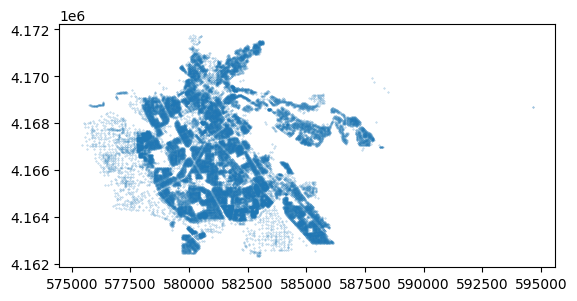

In [14]:
##### PLOT DATA #####
all_data.plot(markersize = 0.1, alpha = 0.5)

##### SAVE JSON FILE #####
fxns.gdf_to_json(all_data.copy(), dir_attribution + 'All_Local_Data_Attributed.json')